In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, f_oneway, kruskal, zscore
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
df = pd.read_csv(r"D:\Cars24_Analysis\Notebooks\bewakoof_cleaned.csv") 

# Univariate Analysis

Text(0.5, 1.0, 'Selling Price Distribution')

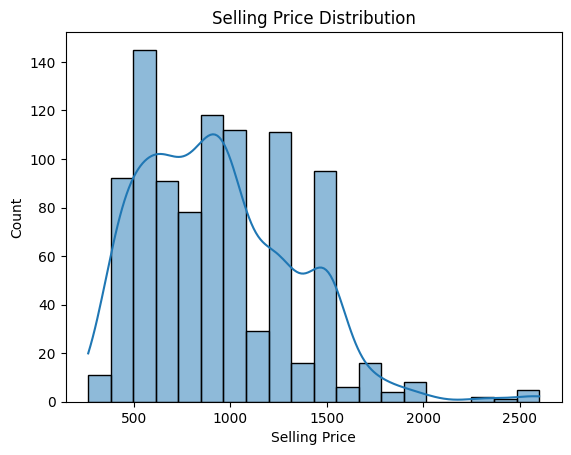

In [3]:
# 1. Selling Price Distribution

sns.histplot(df['Selling Price'], kde=True)
plt.title('Selling Price Distribution')

Text(0.5, 1.0, 'MRP Distribution')

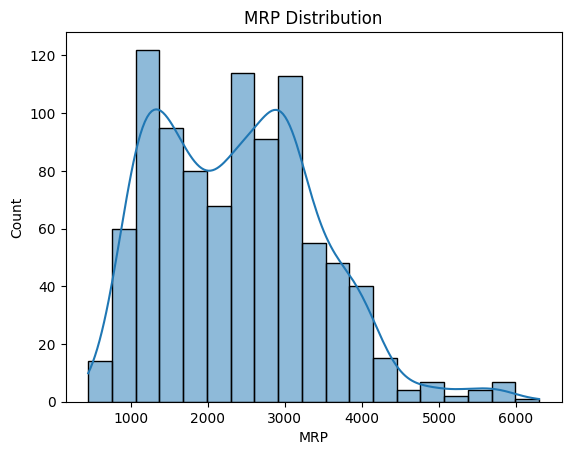

In [4]:
# 2. MRP Distribution

sns.histplot(df['MRP'], kde=True)
plt.title('MRP Distribution')

Text(0.5, 1.0, 'Discount % Distribution')

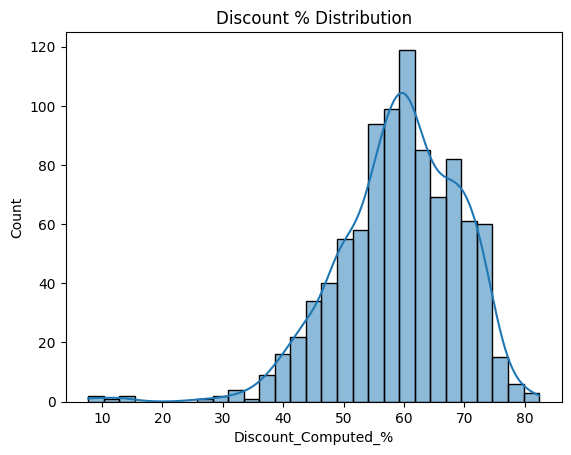

In [5]:
# 3. Discount % Distribution

sns.histplot(df['Discount_Computed_%'], kde=True)
plt.title('Discount % Distribution')

Text(0.5, 1.0, 'Rating Distribution')

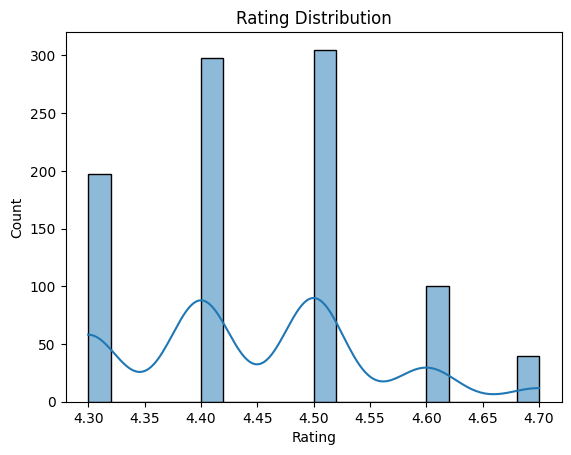

In [6]:
# 4. Rating Distribution

sns.histplot(df['Rating'], kde=True)
plt.title('Rating Distribution')

Text(0.5, 1.0, 'Product Count by Category')

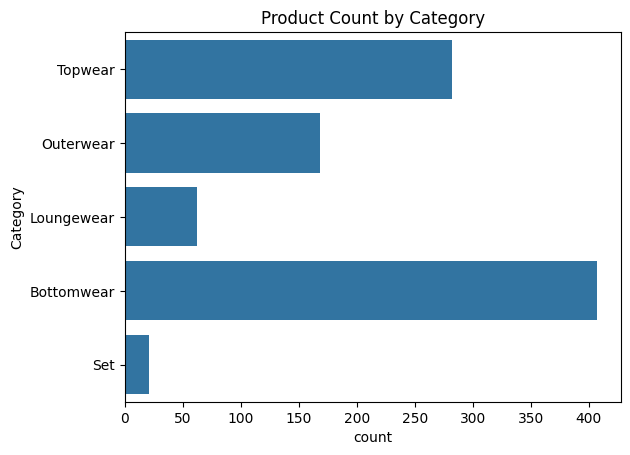

In [7]:
# 5. Category Count
sns.countplot(y='Category', data=df)
plt.title('Product Count by Category')

# Bivariate Analysis

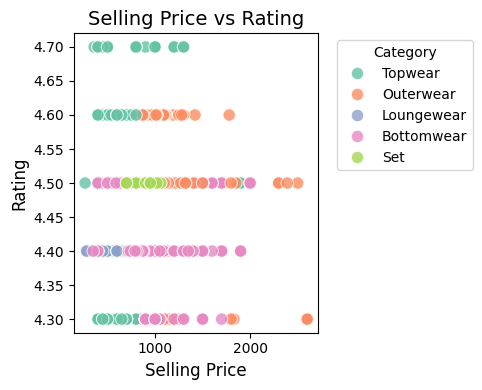

In [8]:
# 6. Selling Price vs Rating


plt.figure(figsize=(5,4))
sns.scatterplot(
    x='Selling Price', 
    y='Rating', 
    hue='Category',       # color by a categorical variable
    palette='Set2',       # colorful palette
    data=df,
    s=80,                 # marker size
    alpha=0.8             # transparency for overlapping points
)
plt.title('Selling Price vs Rating', fontsize=14)
plt.xlabel('Selling Price', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Text(0.5, 1.0, 'Discount % vs Rating')

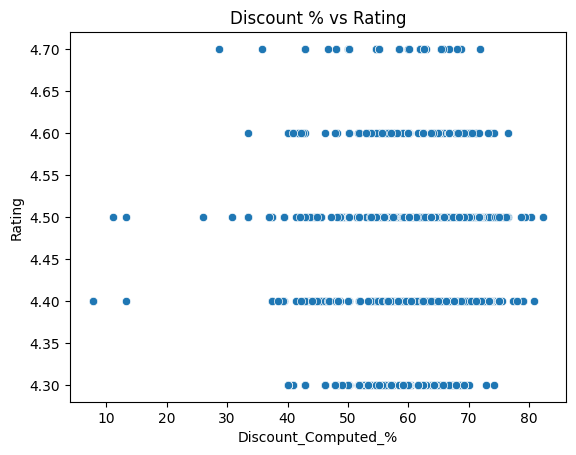

In [9]:
# 7. Discount % vs Rating
sns.scatterplot(x='Discount_Computed_%', y='Rating', data=df)
plt.title('Discount % vs Rating')

Text(0.5, 1.0, 'MRP vs Discount Amount')

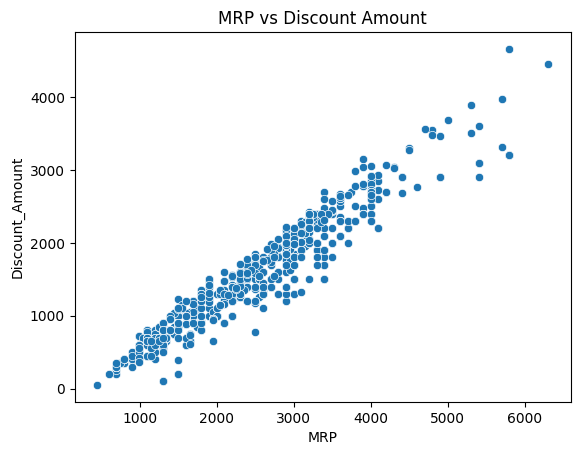

In [10]:
# 8. MRP vs Discount Amount
sns.scatterplot(x='MRP', y='Discount_Amount', data=df)
plt.title('MRP vs Discount Amount')

C:\Users\User\AppData\Local\Temp\ipykernel_31048\2225598083.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y='Selling Price', data=df, palette='Set2')


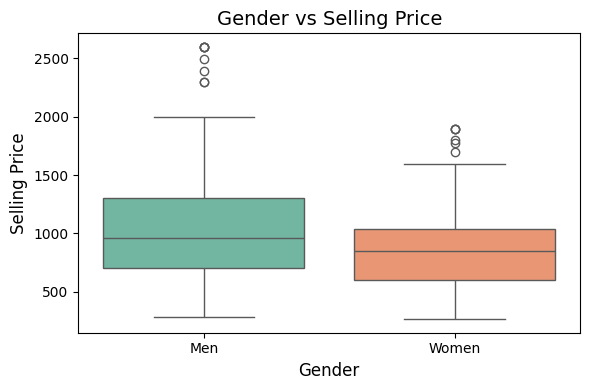

In [11]:
# 9. Gender vs Selling Price
plt.figure(figsize=(6,4))
sns.boxplot(x='Gender', y='Selling Price', data=df, palette='Set2') 
plt.title('Gender vs Selling Price', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Selling Price', fontsize=12)
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_31048\183393716.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y='Discount_Computed_%', data=df,palette='Set2')


Text(0.5, 1.0, 'Category vs Discount %')

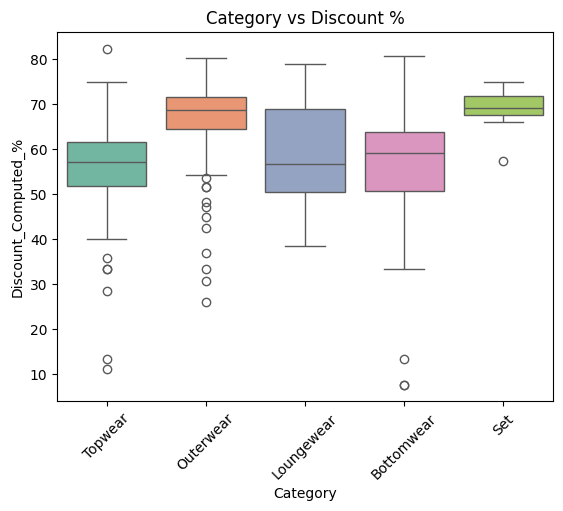

In [12]:
# 10. Category vs Discount %
sns.boxplot(x='Category', y='Discount_Computed_%', data=df,palette='Set2')
plt.xticks(rotation=45)
plt.title('Category vs Discount %')

Text(0.5, 1.0, 'Print Type vs Selling Price')

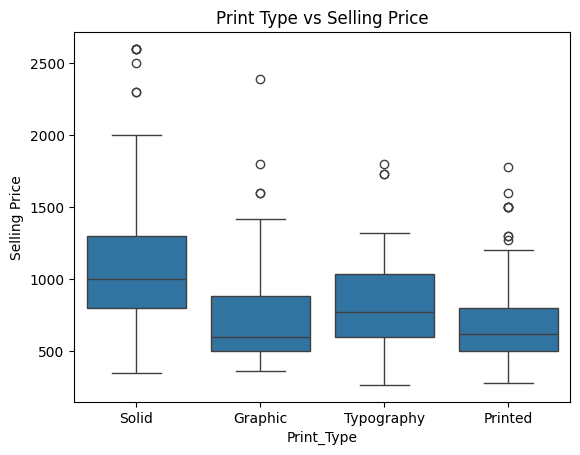

In [13]:
# 11. Print Type vs Selling Price
sns.boxplot(x='Print_Type', y='Selling Price', data=df)
plt.title('Print Type vs Selling Price')

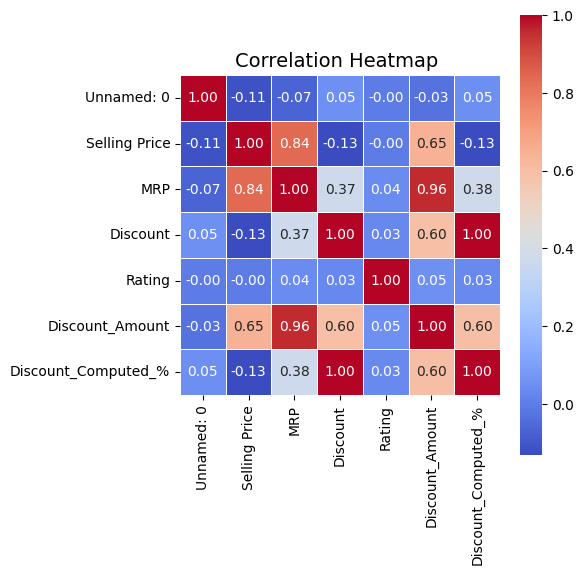

In [14]:
numeric_cols = df.select_dtypes(include='number').columns
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(6,6))
sns.heatmap(
    corr_matrix,
    annot=True,      
    fmt=".2f",
    cmap='coolwarm', 
    linewidths=0.5,
    square=True
)
plt.title('Correlation Heatmap ', fontsize=14)
plt.tight_layout()
plt.show()


In [15]:
from scipy import stats

# 1. Selling Price vs Rating (Pearson Correlation)
corr, p = stats.pearsonr(df['Selling Price'], df['Rating'])
print(f"1. Selling Price vs Rating (Pearson): r = {corr:.3f}, p-value = {p:.4f}")

# 2. Discount % vs Rating (Spearman Correlation)
corr, p = stats.spearmanr(df['Discount_Computed_%'], df['Rating'])
print(f"2. Discount % vs Rating (Spearman): ρ = {corr:.3f}, p-value = {p:.4f}")

# 3. MRP vs Discount Amount (Pearson Correlation)
corr, p = stats.pearsonr(df['MRP'], df['Discount_Amount'])
print(f"3. MRP vs Discount Amount (Pearson): r = {corr:.3f}, p-value = {p:.4f}")

# 4. Gender vs Selling Price (ANOVA)
groups_gender = [g['Selling Price'] for _, g in df.groupby('Gender')]
f_stat, p = stats.f_oneway(*groups_gender)
print(f"4. Gender vs Selling Price (ANOVA): F = {f_stat:.3f}, p-value = {p:.4f}")

# 5. Category vs Discount % (ANOVA)
groups_cat = [g['Discount_Computed_%'] for _, g in df.groupby('Category')]
f_stat, p = stats.f_oneway(*groups_cat)
print(f"5. Category vs Discount % (ANOVA): F = {f_stat:.3f}, p-value = {p:.4f}")

# 6. Product Type vs Rating (ANOVA)
groups_pt = [g['Rating'] for _, g in df.groupby('Product_Type')]
f_stat, p = stats.f_oneway(*groups_pt)
print(f"6. Product Type vs Rating (ANOVA): F = {f_stat:.3f}, p-value = {p:.4f}")

# 7. Print Type vs Selling Price (Independent t-test)
solid = df[df['Print_Type'] == 'Solid']['Selling Price']
printed = df[df['Print_Type'] != 'Solid']['Selling Price']
t_stat, p = stats.ttest_ind(solid, printed, equal_var=False)
print(f"7. Print Type vs Selling Price (t-test): t = {t_stat:.3f}, p-value = {p:.4f}")

# 8. Listed Discount vs Computed Discount (Paired t-test)
t_stat, p = stats.ttest_rel(df['Discount'], df['Discount_Computed_%'])
print(f"8. Listed vs Computed Discount (Paired t-test): t = {t_stat:.3f}, p-value = {p:.4f}")

# 9. Selling Price vs Discount % (Pearson Correlation)
corr, p = stats.pearsonr(df['Selling Price'], df['Discount_Computed_%'])
print(f"9. Selling Price vs Discount % (Pearson): r = {corr:.3f}, p-value = {p:.4f}")


1. Selling Price vs Rating (Pearson): r = -0.004, p-value = 0.9074
2. Discount % vs Rating (Spearman): ρ = 0.076, p-value = 0.0198
3. MRP vs Discount Amount (Pearson): r = 0.957, p-value = 0.0000
4. Gender vs Selling Price (ANOVA): F = 28.979, p-value = 0.0000
5. Category vs Discount % (ANOVA): F = 41.174, p-value = 0.0000
6. Product Type vs Rating (ANOVA): F = 29.788, p-value = 0.0000
7. Print Type vs Selling Price (t-test): t = 12.601, p-value = 0.0000
8. Listed vs Computed Discount (Paired t-test): t = -46.187, p-value = 0.0000
9. Selling Price vs Discount % (Pearson): r = -0.131, p-value = 0.0001


In [16]:
# Interpretation of Statistical Analysis

# Selling Price vs Rating (Pearson r = -0.004, p = 0.9074)

# Interpretation: Essentially no correlation between selling price and customer rating.

# Conclusion: Price does not influence rating for these products.

# Discount % vs Rating (Spearman ρ = 0.076, p = 0.0198)

# Interpretation: Very weak positive correlation between discount percentage and rating.

# Conclusion: Higher discounts are slightly associated with better ratings, but effect is minimal.

# MRP vs Discount Amount (Pearson r = 0.957, p < 0.001)

# Interpretation: Strong positive correlation between MRP and discount amount.

# Conclusion: Higher-priced items tend to have larger absolute discounts.

# Gender vs Selling Price (ANOVA F = 28.979, p < 0.001)

# Interpretation: Significant differences in selling price between genders.

# Conclusion: Men’s and women’s products are priced differently on Bewakoof.

# Category vs Discount % (ANOVA F = 41.174, p < 0.001)

# Interpretation: Significant differences in discount percentages across categories.

# Conclusion: Discounts vary considerably depending on product category.

# Product Type vs Rating (ANOVA F = 29.788, p < 0.001)

# Interpretation: Ratings differ significantly by product type.

# Conclusion: Some product types are rated higher than others by customers.

# Print Type vs Selling Price (t = 12.601, p < 0.001)

# Interpretation: Significant difference in selling price between solid and printed items.

# Conclusion: Print style affects pricing.

# Listed vs Computed Discount (Paired t = -46.187, p < 0.001)

# Interpretation: Significant difference between listed discount and computed discount percentages.

# Conclusion: There may be inconsistencies in discount information on the website.

# Selling Price vs Discount % (Pearson r = -0.131, p = 0.0001)

# Interpretation: Weak negative correlation between selling price and discount %.

# Conclusion: Lower-priced items tend to have slightly higher discount percentages

# 1. Does gender affect the selling price

# Advance Analysis

# 1.Does gender affect the selling price?

In [17]:
groups_gender = [g['Selling Price'] for _, g in df.groupby('Gender')]
f_stat, p = stats.f_oneway(*groups_gender)
print("Does gender affect the selling price?")
if p < 0.05:
    print("→ Yes. Men’s and women’s products are priced differently.\n")
else:
    print("→ No significant difference in pricing between genders.\n")

Does gender affect the selling price?
→ Yes. Men’s and women’s products are priced differently.



# 2. Do discounts vary across product categories?

In [18]:
groups_cat = [g['Discount_Computed_%'] for _, g in df.groupby('Category')]
f_stat, p = stats.f_oneway(*groups_cat)
if p < 0.05:
    print("Yes. Discounts differ significantly between categories.\n")
else:
    print("No significant difference in discounts across categories.\n")

Yes. Discounts differ significantly between categories.



# 3. Does MRP correlate with discount amount? (Pearson Correlation)

In [19]:

corr, p = stats.pearsonr(df['MRP'], df['Discount_Amount'])
if p < 0.05:
    print("Yes. Higher-priced items tend to have larger absolute discounts.\n")
else:
    print("No significant correlation between MRP and discount amount.\n")


Yes. Higher-priced items tend to have larger absolute discounts.



# 4. Are listed discounts consistent with computed discounts? (Paired t-test)

In [20]:

t_stat, p = stats.ttest_rel(df['Discount'], df['Discount_Computed_%'])
if p < 0.05:
    print("No. Some products show inconsistencies in discount information.\n")
else:
    print("Yes. Listed and computed discounts are consistent.\n")

No. Some products show inconsistencies in discount information.



# 5. Does selling price affect discount percentage? (Pearson Correlation)

In [21]:
corr, p = stats.pearsonr(df['Selling Price'], df['Discount_Computed_%'])

if p < 0.05:
    print("Yes. Lower-priced items tend to get slightly higher discounts.\n")
else:
    print("No significant correlation between selling price and discount %.\n")

Yes. Lower-priced items tend to get slightly higher discounts.



In [22]:
# import plotly.express as px
# from plotly.subplots import make_subplots
# import plotly.graph_objects as go

# # =========================
# # Prepare Category Counts
# # =========================
# cat_counts = df["Category"].value_counts().reset_index()
# cat_counts.columns = ["Category", "Count"]

# # =========================
# # Create Subplots
# # =========================
# fig = make_subplots(
#     rows=4, cols=3,
#     subplot_titles=[
#         "Selling Price Distribution",
#         "MRP Distribution",
#         "Discount % Distribution",
#         "Rating Distribution",
#         "Product Count by Category",
#         "Selling Price vs Rating",
#         "Discount % vs Rating",
#         "MRP vs Discount Amount",
#         "Gender vs Selling Price",
#         "Category vs Discount %",
#         "Print Type vs Selling Price",
#         "Numeric Correlation Heatmap"
#     ]
# )

# # =========================
# # UNIVARIATE
# # =========================
# fig.add_trace(px.histogram(df, x="Selling Price").data[0], row=1, col=1)
# fig.add_trace(px.histogram(df, x="MRP").data[0], row=1, col=2)
# fig.add_trace(px.histogram(df, x="Discount_Computed_%").data[0], row=1, col=3)
# fig.add_trace(px.histogram(df, x="Rating").data[0], row=2, col=1)
# fig.add_trace(px.bar(cat_counts, x="Count", y="Category", orientation="h").data[0], row=2, col=2)

# # =========================
# # BIVARIATE
# # =========================
# fig.add_trace(px.scatter(df, x="Selling Price", y="Rating").data[0], row=2, col=3)
# fig.add_trace(px.scatter(df, x="Discount_Computed_%", y="Rating").data[0], row=3, col=1)
# fig.add_trace(px.scatter(df, x="MRP", y="Discount_Amount").data[0], row=3, col=2)
# fig.add_trace(px.box(df, x="Gender", y="Selling Price").data[0], row=3, col=3)
# fig.add_trace(px.box(df, x="Category", y="Discount_Computed_%").data[0], row=4, col=1)
# fig.add_trace(px.box(df, x="Print_Type", y="Selling Price").data[0], row=4, col=2)

# # =========================
# # CORRELATION HEATMAP (Numeric Features)
# # =========================
# numeric_cols = df.select_dtypes(include='number').columns
# corr_matrix = df[numeric_cols].corr()

# heatmap = go.Heatmap(
#     z=corr_matrix.values,
#     x=corr_matrix.columns,
#     y=corr_matrix.columns,
#     colorscale='RdBu',
#     zmin=-1, zmax=1,
#     colorbar=dict(title="Correlation")
# )

# fig.add_trace(heatmap, row=4, col=3)

# # =========================
# # Layout Settings
# # =========================
# fig.update_layout(
#     height=1300,
#     width=1500,
#     title_text="Pricing, Discount & Rating Analysis of Bewakoof Products",
#     showlegend=False
# )

# # =========================
# # Show Figure in Browser
# # =========================
# fig.show(renderer="browser")

# Dashboard

C:\Users\User\AppData\Local\Temp\ipykernel_31048\1585963654.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


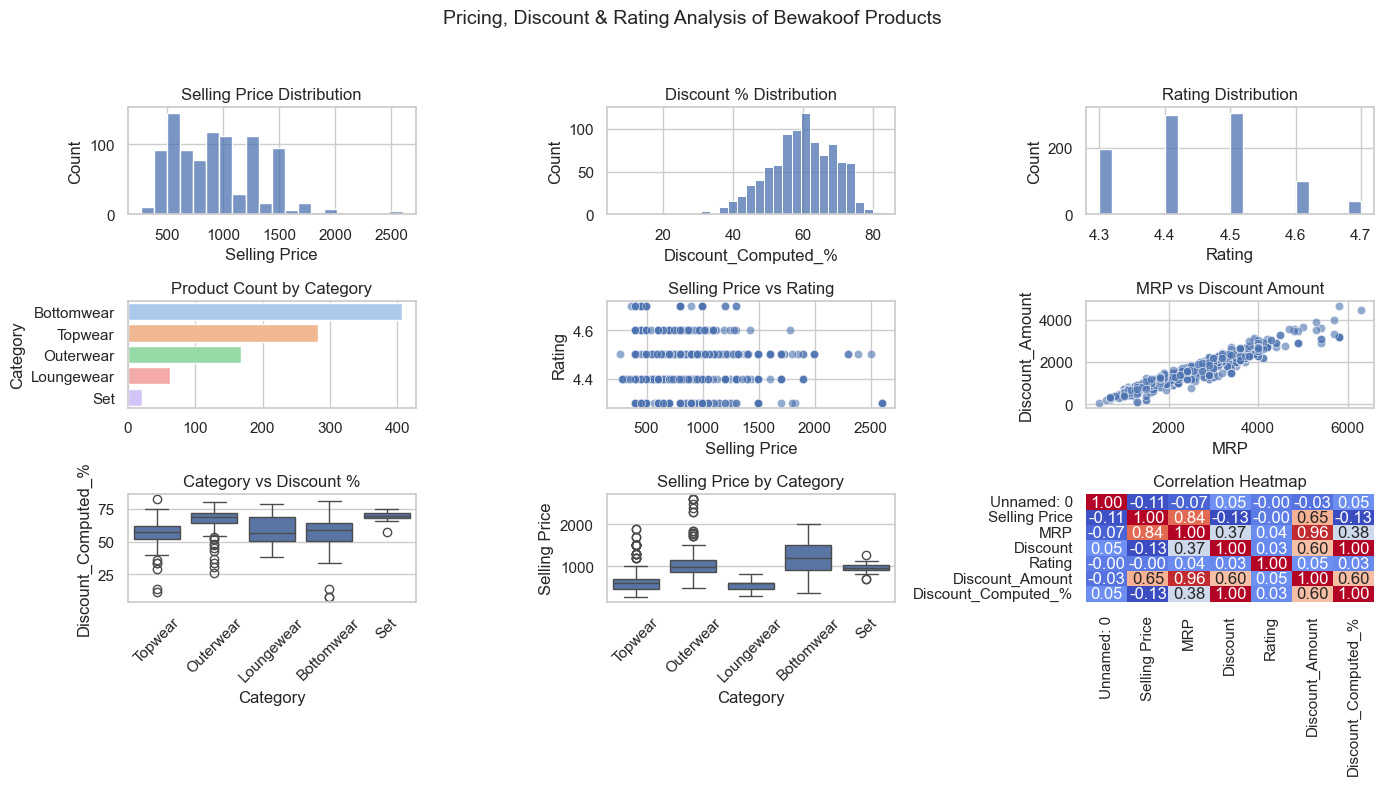

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# -------------------------
# Prepare data
# -------------------------
numeric_cols = df.select_dtypes(include='number').columns
corr_matrix = df[numeric_cols].corr()
cat_counts = df['Category'].value_counts()

# -------------------------
# Create 3x3 subplot grid
# -------------------------
fig, axes = plt.subplots(3, 3, figsize=(14, 8))
fig.suptitle(
    "Pricing, Discount & Rating Analysis of Bewakoof Products",
    fontsize=14
)

# =========================
# Row 1: Core Distributions
# =========================
sns.histplot(df['Selling Price'], ax=axes[0,0], kde=False)
axes[0,0].set_title("Selling Price Distribution")

sns.histplot(df['Discount_Computed_%'], ax=axes[0,1], kde=False)
axes[0,1].set_title("Discount % Distribution")

sns.histplot(df['Rating'], ax=axes[0,2], kde=False)
axes[0,2].set_title("Rating Distribution")

# =========================
# Row 2: Portfolio & Relationships
# =========================
sns.barplot(
    x=cat_counts.values,
    y=cat_counts.index,
    ax=axes[1,0],
    palette="pastel"
)
axes[1,0].set_title("Product Count by Category")

sns.scatterplot(
    x='Selling Price',
    y='Rating',
    data=df,
    ax=axes[1,1],
    alpha=0.6
)
axes[1,1].set_title("Selling Price vs Rating")

sns.scatterplot(
    x='MRP',
    y='Discount_Amount',
    data=df,
    ax=axes[1,2],
    alpha=0.6
)
axes[1,2].set_title("MRP vs Discount Amount")

# =========================
# Row 3: Strategy & Correlation
# =========================
sns.boxplot(
    x='Category',
    y='Discount_Computed_%',
    data=df,
    ax=axes[2,0]
)
axes[2,0].set_title("Category vs Discount %")
axes[2,0].tick_params(axis='x', rotation=45)

sns.boxplot(
    x='Category',
    y='Selling Price',
    data=df,
    ax=axes[2,1]
)
axes[2,1].set_title("Selling Price by Category")
axes[2,1].tick_params(axis='x', rotation=45)

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar=False,
    ax=axes[2,2]
)
axes[2,2].set_title("Correlation Heatmap")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_31048\2077779714.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


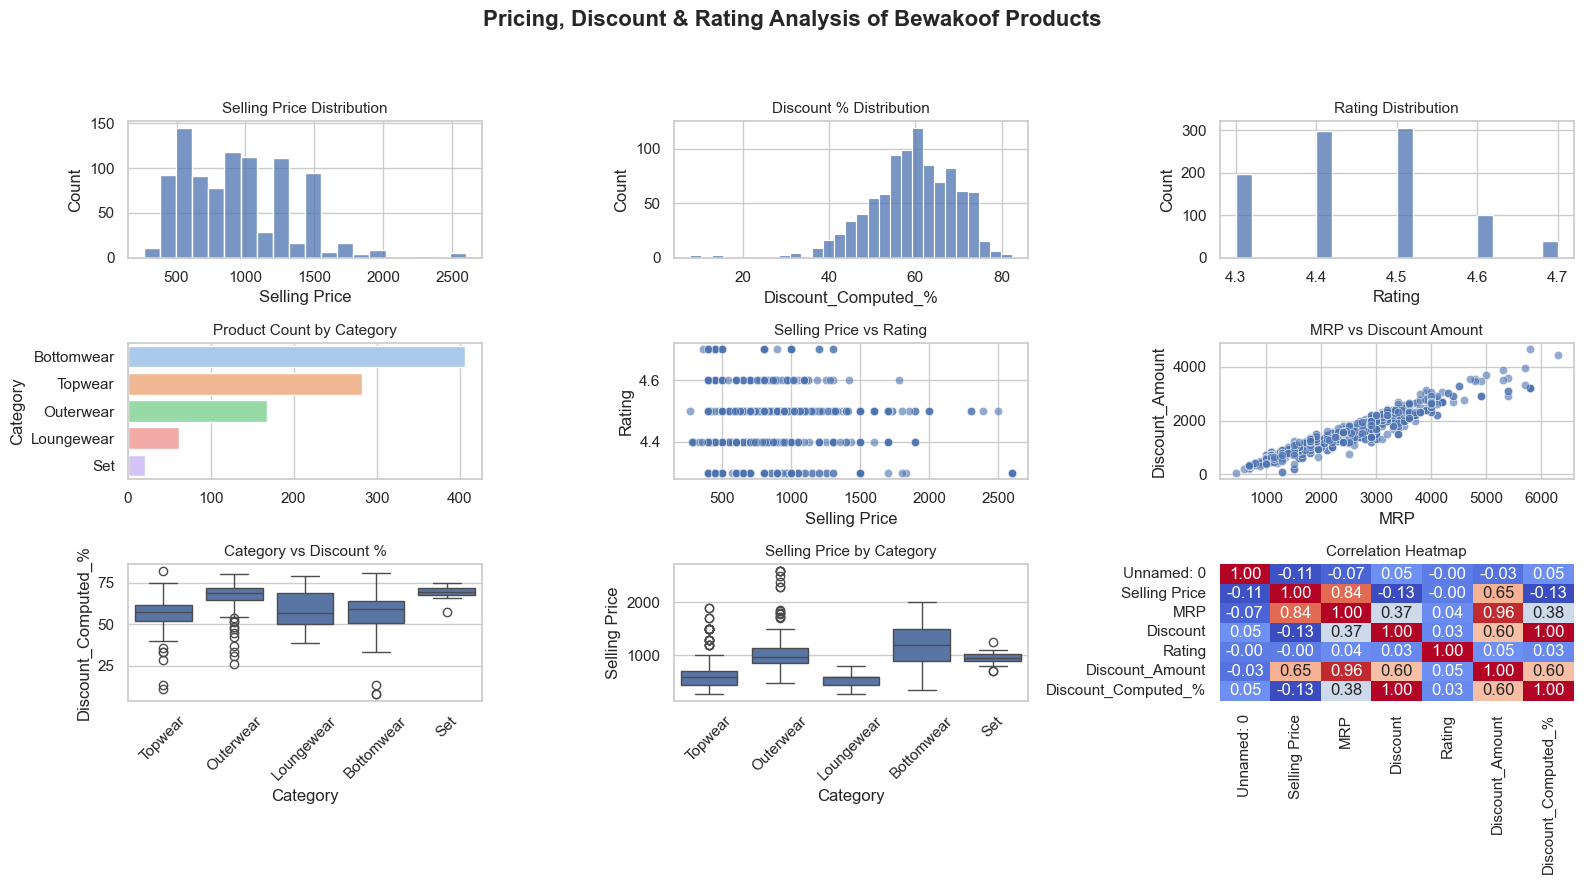

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# -------------------------
# Prepare data
# -------------------------
numeric_cols = df.select_dtypes(include='number').columns
corr_matrix = df[numeric_cols].corr()
cat_counts = df['Category'].value_counts()

# -------------------------
# Create 3x3 subplot grid
# -------------------------
fig, axes = plt.subplots(3, 3, figsize=(16, 9))
fig.suptitle(
    "Pricing, Discount & Rating Analysis of Bewakoof Products",
    fontsize=16,
    fontweight="bold"
)

# =========================
# Row 1: Core Distributions
# =========================
sns.histplot(df['Selling Price'], ax=axes[0,0], kde=False)
axes[0,0].set_title("Selling Price Distribution", fontsize=11)

sns.histplot(df['Discount_Computed_%'], ax=axes[0,1], kde=False)
axes[0,1].set_title("Discount % Distribution", fontsize=11)

sns.histplot(df['Rating'], ax=axes[0,2], kde=False)
axes[0,2].set_title("Rating Distribution", fontsize=11)

# =========================
# Row 2: Portfolio & Relationships
# =========================
sns.barplot(
    x=cat_counts.values,
    y=cat_counts.index,
    ax=axes[1,0],
    palette="pastel"
)
axes[1,0].set_title("Product Count by Category", fontsize=11)

sns.scatterplot(
    x='Selling Price',
    y='Rating',
    data=df,
    ax=axes[1,1],
    alpha=0.6
)
axes[1,1].set_title("Selling Price vs Rating", fontsize=11)

sns.scatterplot(
    x='MRP',
    y='Discount_Amount',
    data=df,
    ax=axes[1,2],
    alpha=0.6
)
axes[1,2].set_title("MRP vs Discount Amount", fontsize=11)

# =========================
# Row 3: Strategy & Correlation
# =========================
sns.boxplot(
    x='Category',
    y='Discount_Computed_%',
    data=df,
    ax=axes[2,0]
)
axes[2,0].set_title("Category vs Discount %", fontsize=11)
axes[2,0].tick_params(axis='x', rotation=45)

sns.boxplot(
    x='Category',
    y='Selling Price',
    data=df,
    ax=axes[2,1]
)
axes[2,1].set_title("Selling Price by Category", fontsize=11)
axes[2,1].tick_params(axis='x', rotation=45)

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar=False,
    ax=axes[2,2]
)
axes[2,2].set_title("Correlation Heatmap", fontsize=11)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_31048\1856771648.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_counts.values, y=cat_counts.index, ax=axes[1,1], palette="pastel")
C:\Users\User\AppData\Local\Temp\ipykernel_31048\1856771648.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y='Selling Price', data=df, ax=axes[2,2], palette="Set2")
C:\Users\User\AppData\Local\Temp\ipykernel_31048\1856771648.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y='Discount_Computed_%', data=df, ax=axes[3,0], pal

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

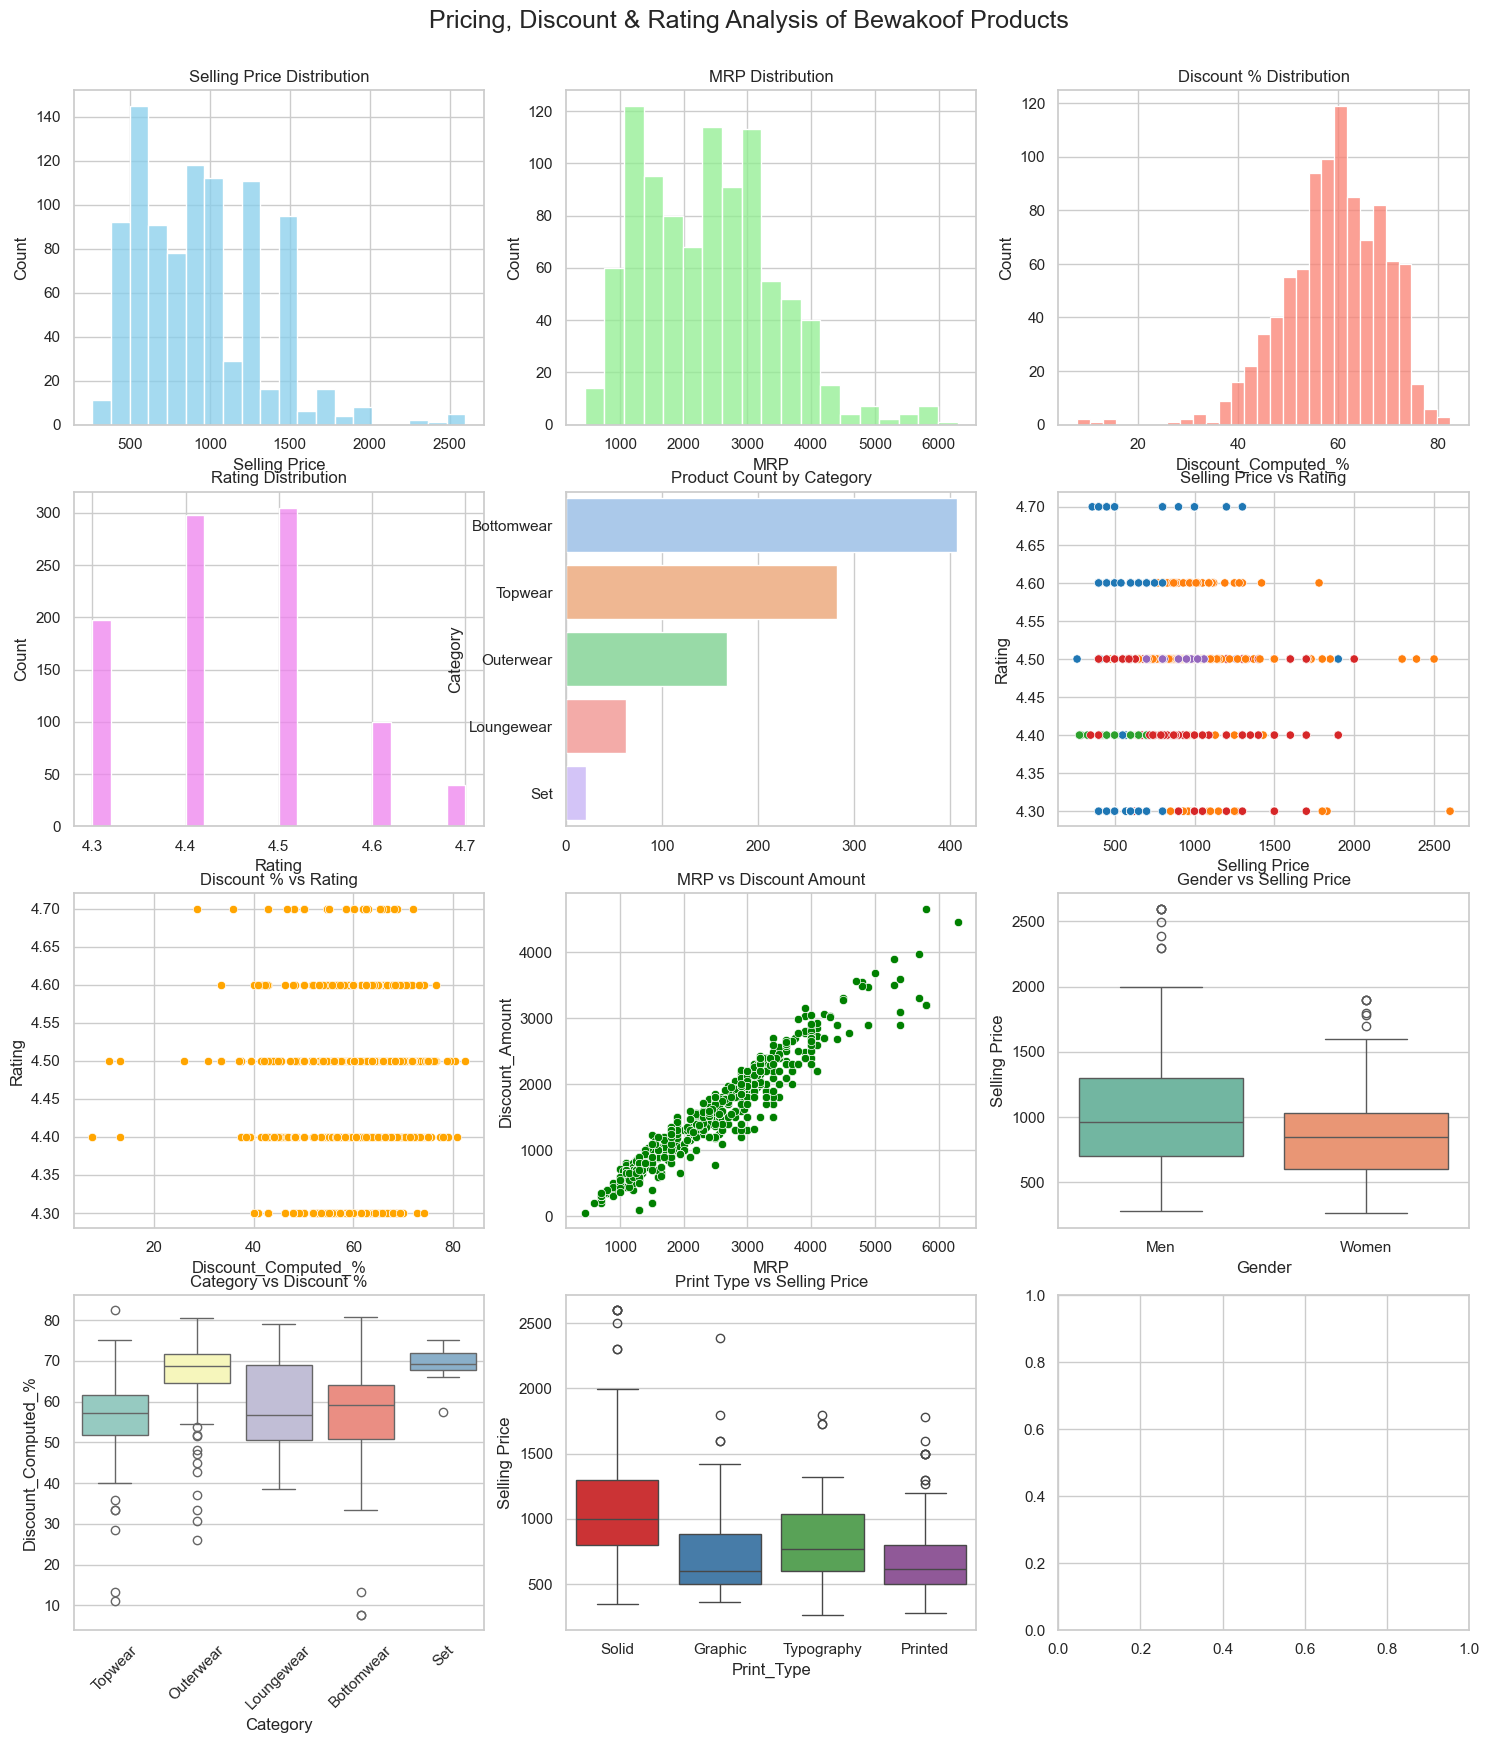

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set Seaborn style
sns.set(style="whitegrid")

# -------------------------
# Prepare data
# -------------------------
# Numeric correlation matrix
numeric_cols = df.select_dtypes(include='number').columns
corr_matrix = df[numeric_cols].corr()

# Category counts
cat_counts = df['Category'].value_counts()

# -------------------------
# Create 4x3 subplot grid
# -------------------------
fig, axes = plt.subplots(4, 3, figsize=(18, 20))
fig.suptitle("Pricing, Discount & Rating Analysis of Bewakoof Products", fontsize=18, y=0.92)

# =========================
# Row 1: Univariate Distributions
# =========================
sns.histplot(df['Selling Price'], ax=axes[0,0], kde=False, color='skyblue')
axes[0,0].set_title("Selling Price Distribution")

sns.histplot(df['MRP'], ax=axes[0,1], kde=False, color='lightgreen')
axes[0,1].set_title("MRP Distribution")

sns.histplot(df['Discount_Computed_%'], ax=axes[0,2], kde=False, color='salmon')
axes[0,2].set_title("Discount % Distribution")

# =========================
# Row 2: Univariate & Bivariate
# =========================
sns.histplot(df['Rating'], ax=axes[1,0], kde=False, color='violet')
axes[1,0].set_title("Rating Distribution")

sns.barplot(x=cat_counts.values, y=cat_counts.index, ax=axes[1,1], palette="pastel")
axes[1,1].set_title("Product Count by Category")

sns.scatterplot(x='Selling Price', y='Rating', data=df, ax=axes[1,2], hue='Category', legend=False, palette="tab10")
axes[1,2].set_title("Selling Price vs Rating")

# =========================
# Row 3: Bivariate
# =========================
sns.scatterplot(x='Discount_Computed_%', y='Rating', data=df, ax=axes[2,0], color='orange')
axes[2,0].set_title("Discount % vs Rating")

sns.scatterplot(x='MRP', y='Discount_Amount', data=df, ax=axes[2,1], color='green')
axes[2,1].set_title("MRP vs Discount Amount")

sns.boxplot(x='Gender', y='Selling Price', data=df, ax=axes[2,2], palette="Set2")
axes[2,2].set_title("Gender vs Selling Price")

# =========================
# Row 4: Boxplots & Heatmap
# =========================
sns.boxplot(x='Category', y='Discount_Computed_%', data=df, ax=axes[3,0], palette="Set3")
axes[3,0].set_title("Category vs Discount %")
axes[3,0].tick_params(axis='x', rotation=45)

sns.boxplot(x='Print_Type', y='Selling Price', data=df, ax=axes[3,1], palette="Set1")
axes[3,1].set_title("Print Type vs Selling Price")

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', ax=axes['3,2'])
axes[3,2].set_title("Correlation Heatmap (Numeric Features)")

# =========================
# Adjust layout
# =========================
plt.tight_layout()
plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_31048\2228152400.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


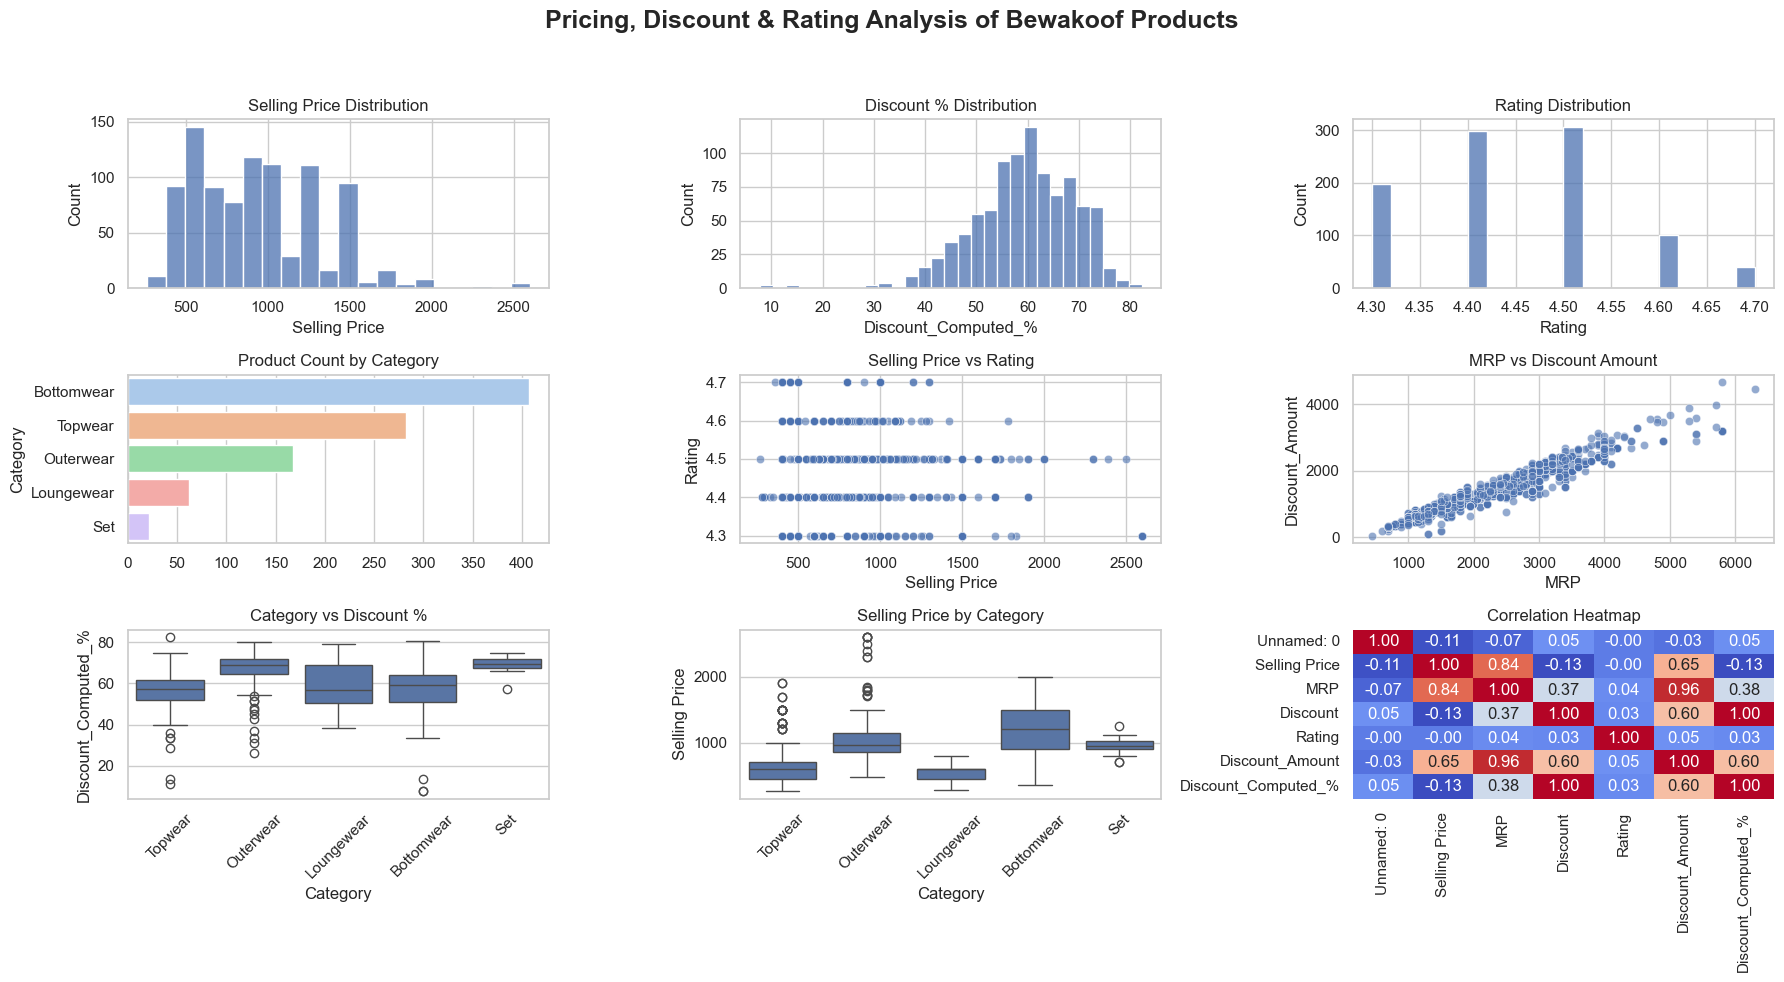

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# -------------------------
# Prepare data
# -------------------------
numeric_cols = df.select_dtypes(include='number').columns
corr_matrix = df[numeric_cols].corr()
cat_counts = df['Category'].value_counts()

# -------------------------
# Create 3x3 subplot grid
# -------------------------
fig, axes = plt.subplots(3, 3, figsize=(18, 10))
fig.suptitle(
    "Pricing, Discount & Rating Analysis of Bewakoof Products",
    fontsize=18,
    fontweight="bold"
)

# =========================
# Row 1: Core Distributions
# =========================
sns.histplot(df['Selling Price'], ax=axes[0,0], kde=False)
axes[0,0].set_title("Selling Price Distribution", fontsize=12)

sns.histplot(df['Discount_Computed_%'], ax=axes[0,1], kde=False)
axes[0,1].set_title("Discount % Distribution", fontsize=12)

sns.histplot(df['Rating'], ax=axes[0,2], kde=False)
axes[0,2].set_title("Rating Distribution", fontsize=12)

# =========================
# Row 2: Portfolio & Relationships
# =========================
sns.barplot(
    x=cat_counts.values,
    y=cat_counts.index,
    ax=axes[1,0],
    palette="pastel"
)
axes[1,0].set_title("Product Count by Category", fontsize=12)

sns.scatterplot(
    x='Selling Price',
    y='Rating',
    data=df,
    ax=axes[1,1],
    alpha=0.6
)
axes[1,1].set_title("Selling Price vs Rating", fontsize=12)

sns.scatterplot(
    x='MRP',
    y='Discount_Amount',
    data=df,
    ax=axes[1,2],
    alpha=0.6
)
axes[1,2].set_title("MRP vs Discount Amount", fontsize=12)

# =========================
# Row 3: Strategy & Correlation
# =========================
sns.boxplot(
    x='Category',
    y='Discount_Computed_%',
    data=df,
    ax=axes[2,0]
)
axes[2,0].set_title("Category vs Discount %", fontsize=12)
axes[2,0].tick_params(axis='x', rotation=45)

sns.boxplot(
    x='Category',
    y='Selling Price',
    data=df,
    ax=axes[2,1]
)
axes[2,1].set_title("Selling Price by Category", fontsize=12)
axes[2,1].tick_params(axis='x', rotation=45)

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar=False,
    ax=axes[2,2]
)
axes[2,2].set_title("Correlation Heatmap", fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# =========================
# Prepare Category Counts
# =========================
cat_counts = df["Category"].value_counts().reset_index()
cat_counts.columns = ["Category", "Count"]

# =========================
# Create Subplots
# =========================
fig = make_subplots(
    rows=4, cols=3,
    subplot_titles=[
        "Selling Price Distribution",
        "MRP Distribution",
        "Discount % Distribution",
        "Rating Distribution",
        "Product Count by Category",
        "Selling Price vs Rating",
        "Discount % vs Rating",
        "MRP vs Discount Amount",
        "Gender vs Selling Price",
        "Category vs Discount %",
        "Print Type vs Selling Price",
        "Numeric Correlation Heatmap"
    ]
)

# =========================
# UNIVARIATE
# =========================
fig.add_trace(px.histogram(df, x="Selling Price").data[0], row=1, col=1)
fig.add_trace(px.histogram(df, x="MRP").data[0], row=1, col=2)
fig.add_trace(px.histogram(df, x="Discount_Computed_%").data[0], row=1, col=3)
fig.add_trace(px.histogram(df, x="Rating").data[0], row=2, col=1)
fig.add_trace(px.bar(cat_counts, x="Count", y="Category", orientation="h").data[0], row=2, col=2)

# =========================
# BIVARIATE
# =========================
fig.add_trace(px.scatter(df, x="Selling Price", y="Rating").data[0], row=2, col=3)
fig.add_trace(px.scatter(df, x="Discount_Computed_%", y="Rating").data[0], row=3, col=1)
fig.add_trace(px.scatter(df, x="MRP", y="Discount_Amount").data[0], row=3, col=2)
fig.add_trace(px.box(df, x="Gender", y="Selling Price").data[0], row=3, col=3)
fig.add_trace(px.box(df, x="Category", y="Discount_Computed_%").data[0], row=4, col=1)
fig.add_trace(px.box(df, x="Print_Type", y="Selling Price").data[0], row=4, col=2)

# =========================
# CORRELATION HEATMAP (Numeric Features)
# =========================
numeric_cols = df.select_dtypes(include='number').columns
corr_matrix = df[numeric_cols].corr()

heatmap = go.Heatmap(
    z=corr_matrix.values,
    x=corr_matrix.columns,
    y=corr_matrix.columns,
    colorscale='RdBu',
    zmin=-1, zmax=1,
    colorbar=dict(title="Correlation")
)

fig.add_trace(heatmap, row=4, col=3)

# =========================
# Layout Settings
# =========================
fig.update_layout(
    height=1300,
    width=1500,
    title_text="Pricing, Discount & Rating Analysis of Bewakoof Products",
    showlegend=False
)

# =========================
# Show Figure in Browser
# =========================
fig.show(renderer="browser")


In [26]:
data=pd.read_csv(r"D:\downloads\agoda_hotels_cleaned.csv")
data.head()

,Hotel Name,Price,Rating,Reviews,Location
0,The Metrostay New Delhi Railway Station,536.0,9.0,295.0,"North Delhi, New Delhi and NCR - City center |..."
1,Palette by CheckIn Royal Retreat Delhi Formerl...,4212.0,8.0,353.0,"South Delhi, New Delhi and NCR - 7.1 km to cen..."
2,Super Townhouse Oak Udyog Vihar,1756.0,8.0,419.0,"Gurugram, New Delhi and NCR - 19.4 km to cente..."
3,The Hosteller Delhi,1756.0,8.0,353.0,N/A | N/A
4,Centaur Hotel,1756.0,8.0,353.0,N/A | N/A


In [31]:
data["Price"].unique()

array([ 536., 4212., 1756.])

In [34]:
data["Location"].value_counts()

Location
N/A | N/A                                                                                                                                          560
North Delhi, New Delhi and NCR - City center | 180 m from Delhi Airport Metro Express • 1.1 km from Chandni Chowk • 1.5 km from Connaught Place     70
South Delhi, New Delhi and NCR - 7.1 km to center | 154 m from Vinobapuri • 1.8 km from Lotus Temple • 3.1 km from Humayun's Tomb                   70
Gurugram, New Delhi and NCR - 19.4 km to center | 2.4 km from Palam Vihar Halt                                                                      70
Name: count, dtype: int64

In [38]:
data["Hotel Name"][650]

'Palette by CheckIn Royal Retreat Delhi Formerly Imperial Villas'

In [27]:
data.isnull().sum()

Hotel Name    0
Price         0
Rating        0
Reviews       0
Location      0
dtype: int64